In [1]:
import numpy as np
from scipy.stats import norm
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
# Pull real PLTR data
stock = yf.download("PLTR", start="2020-01-01", end="2025-01-01", progress=False)

close_prices = stock["Close"]["PLTR"]
daily_returns = close_prices.pct_change().dropna()

S = float(close_prices.iloc[-1])
sigma = float(daily_returns.std() * np.sqrt(252))
K = round(S * 1.05, 2)
T = 1.0
r = 0.05

print(f"PLTR Price:   ${S:.2f}")
print(f"Strike:       ${K:.2f}")
print(f"Volatility:   {sigma*100:.1f}%")

PLTR Price:   $75.63
Strike:       $79.41
Volatility:   71.7%


In [3]:
# Calculate d1 and d2
d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

# Calculate call and put prices
call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

print(f"d1: {d1:.4f}")
print(f"d2: {d2:.4f}")
print(f"Call Price: ${call_price:.2f}")
print(f"Put Price:  ${put_price:.2f}")

d1: 0.3600
d2: -0.3566
Call Price: $21.20
Put Price:  $21.11


In [4]:
# Calculate the 4 Greeks
delta = norm.cdf(d1)
gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
vega = S * norm.pdf(d1) * np.sqrt(T) / 100

print(f"Delta: {delta:.4f}")
print(f"Gamma: {gamma:.4f}")
print(f"Theta: {theta:.4f}")
print(f"Vega:  {vega:.4f}")

Delta: 0.6406
Gamma: 0.0069
Theta: -0.0315
Vega:  0.2828


In [5]:
# Plot how each Greek changes as stock price moves
stock_prices = np.linspace(S * 0.5, S * 1.5, 100)

deltas = []
gammas = []
thetas = []
vegas = []

for price in stock_prices:
    d1_loop = (np.log(price / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_loop = d1_loop - sigma * np.sqrt(T)
    
    deltas.append(norm.cdf(d1_loop))
    gammas.append(norm.pdf(d1_loop) / (price * sigma * np.sqrt(T)))
    thetas.append((-(price * norm.pdf(d1_loop) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2_loop)) / 365)
    vegas.append(price * norm.pdf(d1_loop) * np.sqrt(T) / 100)

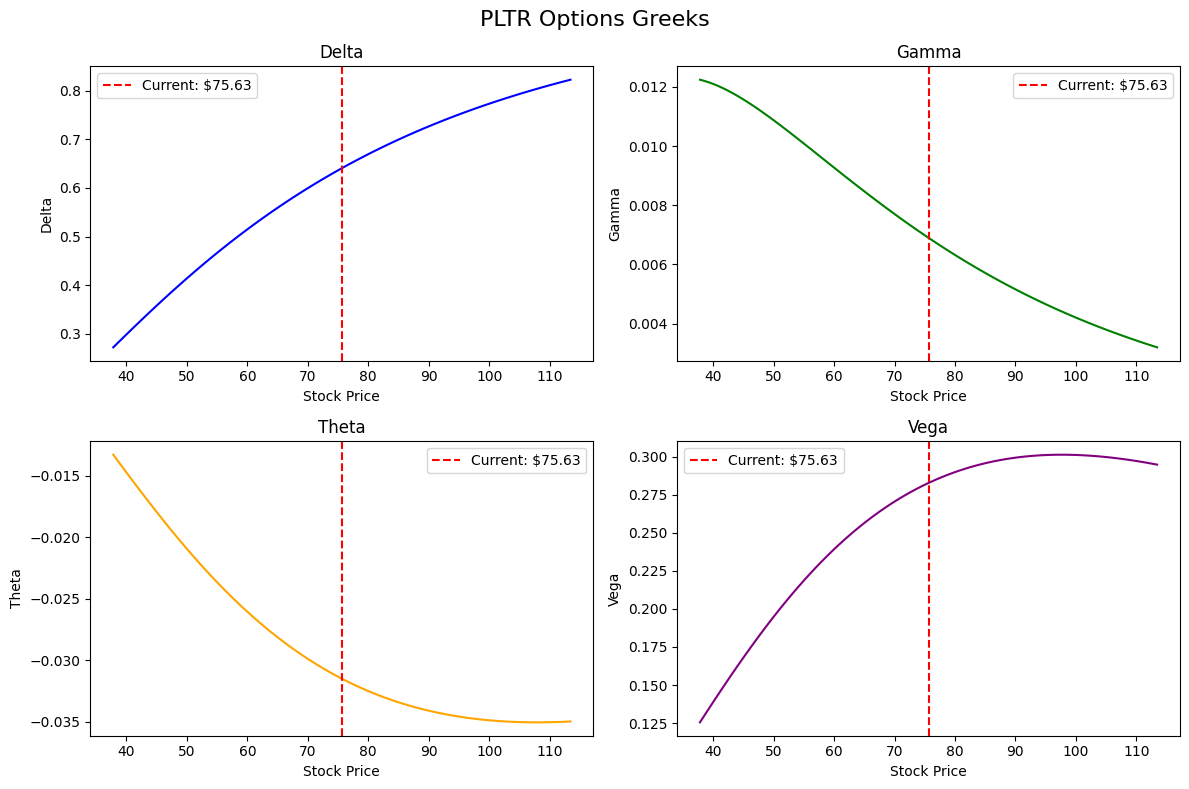

In [6]:
# Plot all 4 Greeks
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("PLTR Options Greeks", fontsize=16)

# Delta
axes[0, 0].plot(stock_prices, deltas, color='blue')
axes[0, 0].set_title("Delta")
axes[0, 0].set_xlabel("Stock Price")
axes[0, 0].set_ylabel("Delta")
axes[0, 0].axvline(x=S, color='red', linestyle='--', label=f'Current: ${S:.2f}')
axes[0, 0].legend()

# Gamma
axes[0, 1].plot(stock_prices, gammas, color='green')
axes[0, 1].set_title("Gamma")
axes[0, 1].set_xlabel("Stock Price")
axes[0, 1].set_ylabel("Gamma")
axes[0, 1].axvline(x=S, color='red', linestyle='--', label=f'Current: ${S:.2f}')
axes[0, 1].legend()

# Theta
axes[1, 0].plot(stock_prices, thetas, color='orange')
axes[1, 0].set_title("Theta")
axes[1, 0].set_xlabel("Stock Price")
axes[1, 0].set_ylabel("Theta")
axes[1, 0].axvline(x=S, color='red', linestyle='--', label=f'Current: ${S:.2f}')
axes[1, 0].legend()

# Vega
axes[1, 1].plot(stock_prices, vegas, color='purple')
axes[1, 1].set_title("Vega")
axes[1, 1].set_xlabel("Stock Price")
axes[1, 1].set_ylabel("Vega")
axes[1, 1].axvline(x=S, color='red', linestyle='--', label=f'Current: ${S:.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [7]:
print("=" * 40)
print("   PLTR Options Greeks Summary")
print("=" * 40)
print(f"Stock Price:  ${S:.2f}")
print(f"Strike Price: ${K:.2f}")
print(f"Call Price:   ${call_price:.2f}")
print(f"Put Price:    ${put_price:.2f}")
print("=" * 40)
print(f"Delta:  {delta:.4f}  → option moves ${delta:.2f} per $1 stock move")
print(f"Gamma:  {gamma:.4f}  → delta changes {gamma:.4f} per $1 stock move")
print(f"Theta:  {theta:.4f}  → loses ${abs(theta):.4f} per day")
print(f"Vega:   {vega:.4f}  → gains ${vega:.4f} per 1% volatility increase")
print("=" * 40)

   PLTR Options Greeks Summary
Stock Price:  $75.63
Strike Price: $79.41
Call Price:   $21.20
Put Price:    $21.11
Delta:  0.6406  → option moves $0.64 per $1 stock move
Gamma:  0.0069  → delta changes 0.0069 per $1 stock move
Theta:  -0.0315  → loses $0.0315 per day
Vega:   0.2828  → gains $0.2828 per 1% volatility increase
